# 03 — RoBERTa-base Full Fine-Tuning with Hybrid Ordinal Loss

This Kaggle-ready notebook fully fine-tunes `roberta_base_en` for balanced five-class Amazon review rating prediction. It combines categorical cross-entropy with an ordinal CDF loss, preserves both the beginning and ending of long reviews, and keeps the previous run's AdamW, warmup/decay, mixed precision, resumable checkpoints, and complete validation reporting.

**Do not use the official test set for model selection.** Labels are mapped from `1..5` to `0..4` for training and converted back for reports.

## Kaggle setup

1. Enable a GPU accelerator in Notebook settings.
2. Add the processed dataset created by `02_preprocessing.ipynb`.
3. Recommended offline-safe setup: choose **Add Input → Models**, search for `keras/roberta`, and attach the Keras model `roberta_base_en` before starting `Save & Run All`. The notebook automatically discovers its local preset under `/kaggle/input`.
4. If no local model is attached, enable Internet so the notebook can fall back to `hf://FacebookAI/roberta-base`.
5. If automatic dataset discovery finds more than one candidate, set `KAGGLE_DATASET_SLUG` in the configuration cell.

The notebook auto-discovers the attached `train.csv` and `validation.csv`; the recommended dataset is `bert_balanced_50000_per_class` (240,000 train and 10,000 validation rows).

In [1]:
import os
import subprocess
import sys

os.environ['KERAS_BACKEND'] = 'tensorflow'

try:
    import keras_hub
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'keras-hub'])
    import keras_hub

import keras
import numpy as np
import pandas as pd
import sklearn
import tensorflow as tf

print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)
print('KerasHub:', keras_hub.__version__)
print('scikit-learn:', sklearn.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2
KerasHub: 0.26.0
scikit-learn: 1.6.1


## Configuration — change paths or experiment settings only here

In [2]:
from pathlib import Path

# Local attached Kaggle Model is preferred; HF is the online fallback.
MODEL_PRESET = 'hf://FacebookAI/roberta-base'
LOCAL_MODEL_PRESET = '/kaggle/input/models/keras/roberta/keras/roberta_base_en/3'  # Optional explicit /kaggle/input/... preset directory.
NUM_CLASSES = 5
MAX_LENGTH = 256
EPOCHS = 3  # Full fine-tuning converges faster than the previous LoRA-only run.
PER_REPLICA_BATCH_SIZE = 8  # Reduce to 4 if full fine-tuning exhausts P100 memory.
USE_MULTI_GPU = False  # Keep False for TF 2.20 + KerasHub 0.26 LoRA stability.
REVIEW_HEAD_WORDS = 96
REVIEW_TAIL_WORDS = 48
ORDINAL_LOSS_WEIGHT = 0.25
PEAK_LEARNING_RATE = 1e-5  # Conservative rate for updating the entire backbone.
END_LEARNING_RATE_RATIO = 0.10
WARMUP_RATIO = 0.05
WEIGHT_DECAY = 0.01
RANDOM_STATE = 42
CHECKPOINT_EVERY_BATCHES = 1000

# Set this when auto-discovery is ambiguous, e.g. 'amazon-balanced-bert-data'.
KAGGLE_DATASET_SLUG = 'datasets/maslri/balanced-50000/bert_balanced_50000_per_class'

INPUT_ROOT = Path('/kaggle/input')
OUTPUT_DIR = Path('/kaggle/working/roberta_full_ordinal')
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
BACKUP_DIR = OUTPUT_DIR / 'training_backup'
LOG_DIR = OUTPUT_DIR / 'logs'
for directory in [OUTPUT_DIR, CHECKPOINT_DIR, LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

keras.utils.set_random_seed(RANDOM_STATE)
tf.config.experimental.enable_op_determinism()

## GPU, mixed precision, and distributed strategy

In [3]:
gpus = tf.config.list_physical_devices('GPU')
if not gpus:
    raise RuntimeError('No GPU detected. Enable a Kaggle GPU accelerator before training.')

keras.mixed_precision.set_global_policy('mixed_float16')

# TF 2.20 + KerasHub 0.26 PipelineModel training previously failed with
# a bool AddN cross-replica reduction under MirroredStrategy on T4x2.
# The default strategy reliably uses GPU:0 without cross-replica reduction.
if USE_MULTI_GPU:
    strategy = tf.distribute.MirroredStrategy()
else:
    strategy = tf.distribute.get_strategy()
GLOBAL_BATCH_SIZE = PER_REPLICA_BATCH_SIZE * strategy.num_replicas_in_sync

print('GPUs:', gpus)
print('Strategy:', type(strategy).__name__)
print('Replicas:', strategy.num_replicas_in_sync)
print('Global batch size:', GLOBAL_BATCH_SIZE)
print('Mixed precision policy:', keras.mixed_precision.global_policy())

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Strategy: _DefaultDistributionStrategy
Replicas: 1
Global batch size: 8
Mixed precision policy: <DTypePolicy "mixed_float16">


## Locate and validate the Kaggle dataset

In [4]:
def find_dataset_file(filename):
    search_root = INPUT_ROOT / KAGGLE_DATASET_SLUG if KAGGLE_DATASET_SLUG else INPUT_ROOT
    candidates = sorted(search_root.rglob(filename))
    valid_candidates = []
    for path in candidates:
        try:
            columns = pd.read_csv(path, nrows=2).columns
            required = {
                'overall', 'verified_str', 'vote_bucket',
                'summary_for_model', 'reviewText',
            }
            if required.issubset(columns):
                valid_candidates.append(path)
        except Exception:
            continue
    if len(valid_candidates) != 1:
        raise FileNotFoundError(
            f'Expected exactly one valid {filename}; found {valid_candidates}. '
            'Set KAGGLE_DATASET_SLUG explicitly.'
        )
    return valid_candidates[0]

TRAIN_PATH = find_dataset_file('train.csv')
VALIDATION_PATH = find_dataset_file('validation.csv')
print('Train:', TRAIN_PATH)
print('Validation:', VALIDATION_PATH)

Train: /kaggle/input/datasets/maslri/balanced-50000/bert_balanced_50000_per_class/train.csv
Validation: /kaggle/input/datasets/maslri/balanced-50000/bert_balanced_50000_per_class/validation.csv


In [5]:
usecols = [
    'overall', 'verified_str', 'vote_bucket',
    'summary_for_model', 'reviewText',
]
train_df = pd.read_csv(TRAIN_PATH, usecols=usecols, low_memory=False)
validation_df = pd.read_csv(VALIDATION_PATH, usecols=usecols, low_memory=False)

for frame in [train_df, validation_df]:
    frame['verified_str'] = frame['verified_str'].fillna('unknown').astype(str)
    frame['vote_bucket'] = frame['vote_bucket'].fillna('missing').astype(str)
    frame['summary_for_model'] = frame['summary_for_model'].fillna('').astype(str)

for name, frame in [('train', train_df), ('validation', validation_df)]:
    assert frame['overall'].between(1, 5).all(), f'Invalid labels in {name}'
    assert frame['reviewText'].notna().all(), f'Missing reviewText in {name}'
    assert frame['reviewText'].astype(str).str.strip().ne('').all(), f'Empty reviewText in {name}'
    print(name, frame.shape, frame['overall'].value_counts().sort_index().to_dict())

def build_head_tail_input(row):
    review_words = str(row['reviewText']).split()
    if len(review_words) > REVIEW_HEAD_WORDS + REVIEW_TAIL_WORDS:
        review = (
            ' '.join(review_words[:REVIEW_HEAD_WORDS])
            + ' ... Review ending: '
            + ' '.join(review_words[-REVIEW_TAIL_WORDS:])
        )
    else:
        review = ' '.join(review_words)
    return (
        f"Verified: {row['verified_str']} | "
        f"Helpful votes: {row['vote_bucket']} | "
        f"Summary: {row['summary_for_model']} | "
        f"Review: {review}"
    )

train_text = train_df.apply(build_head_tail_input, axis=1).to_numpy(dtype=str)
validation_text = validation_df.apply(build_head_tail_input, axis=1).to_numpy(dtype=str)
train_labels = (train_df['overall'].to_numpy(dtype='int32') - 1)
validation_labels = (validation_df['overall'].to_numpy(dtype='int32') - 1)
print('Example model input:', train_text[0][:1000])

train (240000, 5) {1: 48000, 2: 48000, 3: 48000, 4: 48000, 5: 48000}
validation (10000, 5) {1: 2000, 2: 2000, 3: 2000, 4: 2000, 5: 2000}
Example model input: Verified: no | Helpful votes: missing | Summary: XPS8900 Boat Anchor | Review: Purchased direct from DELL: XPS8900 purchased with 256 SSD Drive and 2T HD received with OS setup on 256 SSD for faster boot and better system performance (runs windows 10). Things to know about the XPS8900 and DELL According to Dell tech support, don't waste money on a SSD drive because it serves no purpose in system performance other than saving a few seconds on boot up. The system recovery flash drive that comes with your computer is not it is a watered down Win 10 install only. You will need to go through Dell tech ... Review ending: write protected. Now, I need to go out and get a flash drive, and of course, contact them again to start all over. 9. I am sure this saga will continue for several more iterations before I get a computer that will boot 

## Build efficient `tf.data` pipelines

In [6]:
AUTOTUNE = tf.data.AUTOTUNE
options = tf.data.Options()
options.experimental_deterministic = True

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_text, train_labels))
    .shuffle(len(train_text), seed=RANDOM_STATE, reshuffle_each_iteration=True)
    .batch(GLOBAL_BATCH_SIZE, drop_remainder=True)
    .prefetch(AUTOTUNE)
    .with_options(options)
)
validation_ds = (
    tf.data.Dataset.from_tensor_slices((validation_text, validation_labels))
    .batch(GLOBAL_BATCH_SIZE)
    .prefetch(AUTOTUNE)
    .with_options(options)
)

STEPS_PER_EPOCH = len(train_text) // GLOBAL_BATCH_SIZE
TOTAL_STEPS = STEPS_PER_EPOCH * EPOCHS
WARMUP_STEPS = max(1, int(TOTAL_STEPS * WARMUP_RATIO))
DECAY_STEPS = max(1, TOTAL_STEPS - WARMUP_STEPS)
print({
    'steps_per_epoch': STEPS_PER_EPOCH,
    'total_steps': TOTAL_STEPS,
    'warmup_steps': WARMUP_STEPS,
    'decay_steps': DECAY_STEPS,
})

I0000 00:00:1785906609.323140      25 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


{'steps_per_epoch': 30000, 'total_steps': 90000, 'warmup_steps': 4500, 'decay_steps': 85500}


## Full RoBERTa fine-tuning with categorical + ordinal learning

The previous LoRA experiment plateaued because only attention query/value adapters and the task head were trainable. This run updates the complete backbone. Its loss keeps standard cross-entropy for exact-class micro F1 and adds a CDF distance term so confusing distant ratings is penalized more than confusing adjacent ratings.

For single-label multiclass classification, micro F1 equals accuracy. The metric is named `micro_f1` so checkpoint selection matches the official objective. Macro and weighted F1 are calculated after prediction for diagnostics.

In [7]:
learning_rate = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.0,
    warmup_target=PEAK_LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    decay_steps=DECAY_STEPS,
    alpha=END_LEARNING_RATE_RATIO,
)

@keras.saving.register_keras_serializable(package='AmazonRatings')
class HybridOrdinalCrossentropy(keras.losses.Loss):
    def __init__(self, ordinal_weight=0.25, name='hybrid_ordinal_crossentropy', **kwargs):
        super().__init__(name=name, **kwargs)
        self.ordinal_weight = float(ordinal_weight)

    def call(self, y_true, y_pred):
        y_true = keras.ops.cast(keras.ops.reshape(y_true, (-1,)), 'int32')
        categorical = keras.losses.sparse_categorical_crossentropy(
            y_true, y_pred, from_logits=True
        )
        probabilities = keras.ops.softmax(y_pred, axis=-1)
        targets = keras.ops.one_hot(y_true, NUM_CLASSES)
        predicted_cdf = keras.ops.cumsum(probabilities, axis=-1)[..., :-1]
        target_cdf = keras.ops.cumsum(targets, axis=-1)[..., :-1]
        ordinal = keras.ops.mean(
            keras.ops.square(predicted_cdf - target_cdf), axis=-1
        )
        return categorical + self.ordinal_weight * ordinal

    def get_config(self):
        config = super().get_config()
        config.update({'ordinal_weight': self.ordinal_weight})
        return config

def resolve_roberta_preset():
    if LOCAL_MODEL_PRESET:
        local_path = Path(LOCAL_MODEL_PRESET)
        if not (local_path / 'config.json').exists():
            raise FileNotFoundError(f'No config.json in LOCAL_MODEL_PRESET={local_path}')
        return str(local_path)

    local_candidates = []
    for config_path in INPUT_ROOT.rglob('config.json'):
        candidate = config_path.parent
        candidate_text = str(candidate).lower()
        has_tokenizer = (candidate / 'tokenizer.json').exists()
        if 'roberta' in candidate_text and has_tokenizer:
            local_candidates.append(candidate)

    local_candidates = sorted(set(local_candidates))
    if len(local_candidates) == 1:
        print('Using attached offline Kaggle Model preset.')
        return str(local_candidates[0])
    if len(local_candidates) > 1:
        raise RuntimeError(
            f'Multiple local RoBERTa presets found: {local_candidates}. '
            'Set LOCAL_MODEL_PRESET explicitly.'
        )

    import socket
    try:
        socket.gethostbyname('huggingface.co')
    except OSError as error:
        raise RuntimeError(
            'No attached RoBERTa preset was found and Kaggle Internet/DNS is disabled. '
            'Use Add Input -> Models -> keras/roberta -> roberta_base_en, '
            'then restart and run the notebook again.'
        ) from error
    print('No local preset found; using the online Hugging Face fallback.')
    return MODEL_PRESET

effective_model_preset = resolve_roberta_preset()
print('Loading preset:', effective_model_preset)

with strategy.scope():
    model = keras_hub.models.RobertaTextClassifier.from_preset(
        effective_model_preset,
        num_classes=NUM_CLASSES,
        activation=None,
        dropout=0.1,
    )
    model.preprocessor.sequence_length = MAX_LENGTH
    optimizer = keras.optimizers.AdamW(
        learning_rate=learning_rate,
        weight_decay=WEIGHT_DECAY,
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-6,
        global_clipnorm=1.0,
    )
    optimizer.exclude_from_weight_decay(var_names=['bias', 'beta', 'gamma'])
    loss = HybridOrdinalCrossentropy(ordinal_weight=ORDINAL_LOSS_WEIGHT)
    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=[keras.metrics.SparseCategoricalAccuracy(name='micro_f1')],
        jit_compile=False,
    )

trainable_parameters = int(sum(np.prod(variable.shape) for variable in model.trainable_weights))
total_parameters = int(sum(np.prod(variable.shape) for variable in model.weights))
trainable_percentage = 100.0 * trainable_parameters / total_parameters

print(f'Trainable parameters: {trainable_parameters:,}')
print(f'Total parameters: {total_parameters:,}')
print(f'Trainable percentage: {trainable_percentage:.4f}%')
model.summary()

Loading preset: /kaggle/input/models/keras/roberta/keras/roberta_base_en/3
Trainable parameters: 124,647,173
Total parameters: 124,647,173
Trainable percentage: 100.0000%


Preprocessor: "roberta_text_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ roberta_tokenizer (RobertaTokenizer)                          │                       Vocab size: 50,265 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "roberta_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ roberta_backbone              │ (None, None, 768)         │     124,052,736 │ padding_mask[0][0],        │
│ (RobertaBackbone)             │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 768)               │               0 │ roberta_backbone[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dropout (Dropout)      │ (None, 768)               │               0 │ get_item[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ pooled_dropout[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_dropout (Dropout)      │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 5)                 │           3,845 │ output_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 124,647,173 (475.49 MB)

 Trainable params: 124,647,173 (475.49 MB)

 Non-trainable params: 0 (0.00 B)

## Fault-tolerant callbacks and checkpoint strategy

Periodic checkpoints are intentionally less frequent than in the LoRA run because full-model checkpoints are large. Weights alone do not guarantee exact continuation of optimizer and learning-rate-schedule state, so `BackupAndRestore` remains the primary resume mechanism.

- `training_backup/`: resumable training state; automatically restored when the same notebook is rerun.
- `latest.weights.h5`: emergency periodic weights.
- `best.weights.h5`: best epoch by validation micro F1.
- `roberta_full_ordinal_classifier.keras`: final serializable full model.

Kaggle `/kaggle/working` is not durable across a completely discarded session. Save a Kaggle notebook version or download the output directory before ending the session.

In [8]:
callbacks = [
    keras.callbacks.BackupAndRestore(
        backup_dir=str(BACKUP_DIR),
        save_freq=CHECKPOINT_EVERY_BATCHES,
        double_checkpoint=True,
        delete_checkpoint=False,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(CHECKPOINT_DIR / 'latest.weights.h5'),
        save_weights_only=True,
        save_freq=CHECKPOINT_EVERY_BATCHES,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(CHECKPOINT_DIR / 'best.weights.h5'),
        monitor='val_micro_f1',
        mode='max',
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_micro_f1',
        mode='max',
        patience=2,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.CSVLogger(str(LOG_DIR / 'training.csv'), append=True),
    keras.callbacks.TensorBoard(log_dir=str(LOG_DIR / 'tensorboard'), update_freq=100),
    keras.callbacks.TerminateOnNaN(),
]

## Train

This is the long-running cell. If interrupted, rerun the notebook with the same output files present; `BackupAndRestore` resumes from its latest saved training state.

In [9]:
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/3


2026-08-05 05:10:28.224537: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_24}}


  999/30000 ━━━━━━━━━━━━━━━━━━━━ 2:40:18 332ms/step - loss: 1.6667 - micro_f1: 0.1963
Epoch 1: saving model to /kaggle/working/roberta_full_ordinal/checkpoints/latest.weights.h5

Epoch 1: finished saving model to /kaggle/working/roberta_full_ordinal/checkpoints/latest.weights.h5
 1999/30000 ━━━━━━━━━━━━━━━━━━━━ 2:37:57 338ms/step - loss: 1.5569 - micro_f1: 0.2644
Epoch 1: saving model to /kaggle/working/roberta_full_ordinal/checkpoints/latest.weights.h5

Epoch 1: finished saving model to /kaggle/working/roberta_full_ordinal/checkpoints/latest.weights.h5
 2999/30000 ━━━━━━━━━━━━━━━━━━━━ 2:34:03 342ms/step - loss: 1.4561 - micro_f1: 0.3223
Epoch 1: saving model to /kaggle/working/roberta_full_ordinal/checkpoints/latest.weights.h5

Epoch 1: finished saving model to /kaggle/working/roberta_full_ordinal/checkpoints/latest.weights.h5
 3999/30000 ━━━━━━━━━━━━━━━━━━━━ 2:29:15 344ms/step - loss: 1.3835 - micro_f1: 0.3625
Epoch 1: saving model to /kaggle/working/roberta_full_ordinal/checkpoints/

2026-08-05 08:07:41.683649: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_19}}



Epoch 1: val_micro_f1 improved from None to 0.67760, saving model to /kaggle/working/roberta_full_ordinal/checkpoints/best.weights.h5

Epoch 1: finished saving model to /kaggle/working/roberta_full_ordinal/checkpoints/best.weights.h5
30000/30000 ━━━━━━━━━━━━━━━━━━━━ 10765s 357ms/step - loss: 0.8749 - micro_f1: 0.6291 - val_loss: 0.7698 - val_micro_f1: 0.6776
Epoch 2/3
  999/30000 ━━━━━━━━━━━━━━━━━━━━ 2:38:57 329ms/step - loss: 0.7327 - micro_f1: 0.6999
Epoch 2: saving model to /kaggle/working/roberta_full_ordinal/checkpoints/latest.weights.h5

Epoch 2: finished saving model to /kaggle/working/roberta_full_ordinal/checkpoints/latest.weights.h5
 1999/30000 ━━━━━━━━━━━━━━━━━━━━ 2:40:27 344ms/step - loss: 0.7329 - micro_f1: 0.6984
Epoch 2: saving model to /kaggle/working/roberta_full_ordinal/checkpoints/latest.weights.h5

Epoch 2: finished saving model to /kaggle/working/roberta_full_ordinal/checkpoints/latest.weights.h5
 2999/30000 ━━━━━━━━━━━━━━━━━━━━ 2:35:47 346ms/step - loss: 0.7319 -

2026-08-05 11:05:03.546998: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_19}}



Epoch 2: val_micro_f1 improved from 0.67760 to 0.68510, saving model to /kaggle/working/roberta_full_ordinal/checkpoints/best.weights.h5

Epoch 2: finished saving model to /kaggle/working/roberta_full_ordinal/checkpoints/best.weights.h5
30000/30000 ━━━━━━━━━━━━━━━━━━━━ 10635s 354ms/step - loss: 0.7304 - micro_f1: 0.6959 - val_loss: 0.7754 - val_micro_f1: 0.6851
Epoch 3/3
  999/30000 ━━━━━━━━━━━━━━━━━━━━ 2:38:54 329ms/step - loss: 0.6561 - micro_f1: 0.7322
Epoch 3: saving model to /kaggle/working/roberta_full_ordinal/checkpoints/latest.weights.h5

Epoch 3: finished saving model to /kaggle/working/roberta_full_ordinal/checkpoints/latest.weights.h5
 1999/30000 ━━━━━━━━━━━━━━━━━━━━ 2:40:53 345ms/step - loss: 0.6586 - micro_f1: 0.7289
Epoch 3: saving model to /kaggle/working/roberta_full_ordinal/checkpoints/latest.weights.h5

Epoch 3: finished saving model to /kaggle/working/roberta_full_ordinal/checkpoints/latest.weights.h5
 2999/30000 ━━━━━━━━━━━━━━━━━━━━ 2:36:48 348ms/step - loss: 0.657

2026-08-05 14:02:49.525972: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_19}}



Epoch 3: val_micro_f1 improved from 0.68510 to 0.69480, saving model to /kaggle/working/roberta_full_ordinal/checkpoints/best.weights.h5

Epoch 3: finished saving model to /kaggle/working/roberta_full_ordinal/checkpoints/best.weights.h5
30000/30000 ━━━━━━━━━━━━━━━━━━━━ 10665s 355ms/step - loss: 0.6475 - micro_f1: 0.7368 - val_loss: 0.7878 - val_micro_f1: 0.6948
Restoring model weights from the end of the best epoch: 3.


## Load best weights and compute complete validation metrics

In [10]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

best_weights_path = CHECKPOINT_DIR / 'best.weights.h5'
if best_weights_path.exists():
    model.load_weights(best_weights_path)

validation_logits = model.predict(validation_ds, verbose=1)
validation_prediction_zero_based = np.argmax(validation_logits, axis=1)
validation_prediction = validation_prediction_zero_based + 1
validation_truth = validation_labels + 1

metrics = {
    'accuracy': accuracy_score(validation_truth, validation_prediction),
    'micro_f1': f1_score(validation_truth, validation_prediction, average='micro'),
    'macro_f1': f1_score(validation_truth, validation_prediction, average='macro'),
    'weighted_f1': f1_score(validation_truth, validation_prediction, average='weighted'),
}
print(metrics)
print(classification_report(validation_truth, validation_prediction, digits=4))

2026-08-05 14:05:20.460495: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_19}}


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 121s 93ms/step
{'accuracy': 0.6948, 'micro_f1': 0.6948, 'macro_f1': 0.6960165070917919, 'weighted_f1': 0.696016507091792}
              precision    recall  f1-score   support

           1     0.7659    0.7410    0.7532      2000
           2     0.5848    0.6395    0.6109      2000
           3     0.6190    0.6215    0.6203      2000
           4     0.6891    0.6605    0.6745      2000
           5     0.8310    0.8115    0.8211      2000

    accuracy                         0.6948     10000
   macro avg     0.6980    0.6948    0.6960     10000
weighted avg     0.6980    0.6948    0.6960     10000



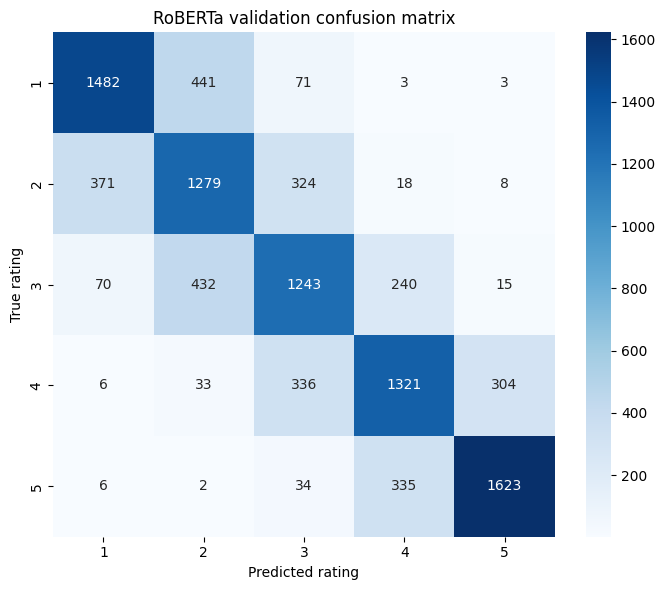

117

In [11]:
import json
import matplotlib.pyplot as plt
import seaborn as sns

matrix = confusion_matrix(validation_truth, validation_prediction, labels=[1, 2, 3, 4, 5])
plt.figure(figsize=(7, 6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
plt.xlabel('Predicted rating')
plt.ylabel('True rating')
plt.title('RoBERTa validation confusion matrix')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=160)
plt.show()

pd.DataFrame({
    'true_rating': validation_truth,
    'predicted_rating': validation_prediction,
}).to_csv(OUTPUT_DIR / 'validation_predictions.csv', index=False)

(OUTPUT_DIR / 'validation_metrics.json').write_text(
    json.dumps(metrics, indent=2) + '\n', encoding='utf-8'
)

## Save final model artifacts

In [12]:
model.save(OUTPUT_DIR / 'roberta_full_ordinal_classifier.keras')
model.save_to_preset(OUTPUT_DIR / 'roberta_full_ordinal_classifier_preset')

parameter_stats = {
    'fine_tuning_mode': 'full_backbone',
    'ordinal_loss_weight': ORDINAL_LOSS_WEIGHT,
    'review_head_words': REVIEW_HEAD_WORDS,
    'review_tail_words': REVIEW_TAIL_WORDS,
    'trainable_parameters': trainable_parameters,
    'total_parameters': total_parameters,
    'trainable_percentage': trainable_percentage,
}
(OUTPUT_DIR / 'parameter_stats.json').write_text(
    json.dumps(parameter_stats, indent=2) + '\n', encoding='utf-8'
)

print('Artifacts:')
for path in sorted(OUTPUT_DIR.rglob('*')):
    if path.is_file():
        print(path.relative_to(OUTPUT_DIR), f'{path.stat().st_size / 1024**2:.2f} MB')

Artifacts:
checkpoints/best.weights.h5 2378.18 MB
checkpoints/latest.weights.h5 2378.18 MB
confusion_matrix.png 0.06 MB
logs/tensorboard/train/events.out.tfevents.1785906627.79114352086e.25.0.v2 12.33 MB
logs/tensorboard/validation/events.out.tfevents.1785917261.79114352086e.25.1.v2 0.00 MB
logs/training.csv 0.00 MB
parameter_stats.json 0.00 MB
roberta_full_ordinal_classifier.keras 2379.60 MB
roberta_full_ordinal_classifier_preset/assets/tokenizer/merges.txt 0.44 MB
roberta_full_ordinal_classifier_preset/assets/tokenizer/vocabulary.json 0.99 MB
roberta_full_ordinal_classifier_preset/config.json 0.00 MB
roberta_full_ordinal_classifier_preset/metadata.json 0.00 MB
roberta_full_ordinal_classifier_preset/model.weights.h5 473.63 MB
roberta_full_ordinal_classifier_preset/preprocessor.json 0.00 MB
roberta_full_ordinal_classifier_preset/task.json 0.00 MB
roberta_full_ordinal_classifier_preset/task.weights.h5 2378.18 MB
roberta_full_ordinal_classifier_preset/tokenizer.json 0.00 MB
training_back

## Notes for the next stage

- Select the model by validation micro F1; use macro F1 to diagnose minority/adjacent-rating behaviour.
- Do not tune against the official test set.
- If GPU memory is exhausted, lower `PER_REPLICA_BATCH_SIZE` from 8 to 4; keep `MAX_LENGTH=256` when possible.
- If training is stable but still improves at epoch 3, resume for one controlled fourth epoch.
- Compare this full ordinal run with the completed LoRA baseline on the same validation split.
- A score near 0.80 on balanced exact-star prediction is not guaranteed; class 2/3/4 F1 and the confusion matrix determine whether ordinal learning helped.